# What do measured oscillations tell me about a star?

This tutorial uses the measured global asteroseismic quantities `numax` ($\nu_{\max}$) and `dnu` ($\Delta\nu$) to infer stellar mass, radius, mean density, and surface gravity. These are scaling-relation estimates rather than fits to individual oscillation modes or stellar evolutionary tracks.

In [2]:
import asteroscale as ast

## A quick point prediction


For a quick back-of-the-envelope estimate, supply plain values without uncertainties. Here we use solar values of $\nu_{\max}$, $\Delta\nu$, effective temperature, and metallicity to recover a point estimate of mass and radius. A plain value is treated as exact; it does not mean the real measurement has zero uncertainty.

In [3]:
star = {"numax": 3090, # microhertz
        "dnu": 135.1, # microhertz
        "Teff": 5777, # Kelvin
        "FeH": 0.0, # dex; solar metallicity
        } 

prediction = ast.solve(star,
                       want=["M", "R"], # both are in solar units.
                       )
prediction

{'M': np.float64(1.033601728549608), 'R': np.float64(1.009531747846707)}

The inputs correspond approximately to the Sun, so the returned mass and radius should be close to one in solar units. We supplied `FeH=0.0` because the adopted seismic relations include metallicity-dependent corrections. In an uncertain calculation, an omitted metallicity is marginalized over its prior; in an exact inversion, supplying it makes the problem fully specified and easier to interpret.

## Inference with uncertainties

To propagate uncertainties, supply a `(value, error)` pair. AsteroScale interprets this as the mean and independent Gaussian $1\sigma$ uncertainty and launches the sampler. The returned arrays approximate the distributions of the requested quantities.

We retain the metallicity constraint because both seismic relations include a composition-dependent correction.

param             mean         std         p16         p50         p84
----------------------------------------------------------------------
M               0.9982      0.0303      0.9695      0.9974       1.031
R               0.9991     0.01002      0.9897      0.9989        1.01


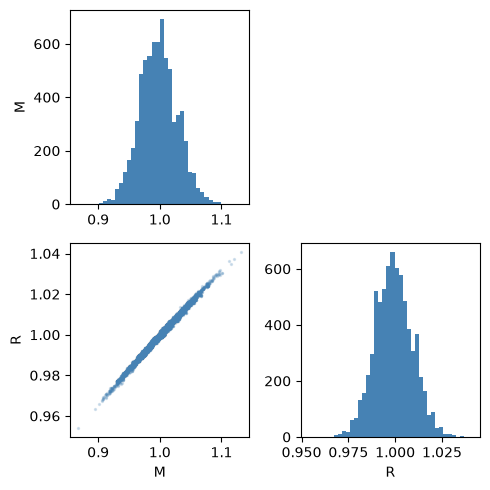

In [5]:
given = {"Teff": (5777, 50),
         "numax": (3090, 30),
         "dnu": (135.1, 0.1),
         "FeH": (0.0, 0.01)
        }

solver = ast.Solver()
samples = solver.solve(given, want=["M", "R"])
ast.summarize(samples)
fig = ast.plot_posterior(samples)

## Sampling presets

Sampling may take longer when the supplied data leave broad or strongly correlated solutions. AsteroScale provides `fast` for an initial check, `standard` for ordinary work, and `precise` for a more expensive calculation.

**Important:** `precise` also enables empirical scatter in the scaling relations; `fast` and `standard` disable it by default. The wider relation model gives the mass and radius priors more influence, so posterior medians can move as well as broaden. Read the calibration-and-scatter concept page before treating differences as purely numerical convergence.

In [6]:
for preset in ("fast", "standard", "precise"):
    print(preset, ast.Solver(preset=preset).settings)

fast SamplerSettings(nlive=200, dlogz=1.0, sample='rwalk', bound='single', bootstrap=0, walks=5, update_interval=200)
standard SamplerSettings(nlive=500, dlogz=0.1, sample='rwalk', bound='single', bootstrap=0, walks=10, update_interval=500)
precise SamplerSettings(nlive=1000, dlogz=0.01, sample='rwalk', bound='single', bootstrap=0, walks=20, update_interval=1000)


## Calculate additional quantities without sampling again

To calculate additional derived quantities without rerunning the sampler, use the solver's `predict()` method. It reuses the posterior samples from the most recent `solve()` call.

In [7]:
extra = solver.predict(["L", "rho", "logg"])
ast.summarize(extra)

param             mean         std         p16         p50         p84
----------------------------------------------------------------------
L                1.001     0.04346      0.9569       1.001       1.044
rho                  1    0.002385      0.9981           1       1.003
logg             4.438     0.00454       4.433       4.437       4.442
